## **Read Data**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

data_path = '/kaggle/input/datasets/sohaibdevv/ai-and-data-science-job-market-2025-2026/AI_Job_Market_Trends_2026.csv'
df = pd.read_csv(data_path)

df.head()

,job_id,job_title,company_size,company_industry,country,remote_type,experience_level,years_experience,education_level,skills_python,skills_sql,skills_ml,skills_deep_learning,skills_cloud,salary,job_posting_month,job_posting_year,hiring_urgency,job_openings
0,1,AI Engineer,Startup,Retail,Canada,Remote,Senior,2,Master,0,0,0,1,0,158322,6,2024,Low,4
1,2,Machine Learning Engineer,MNC,Technology,Australia,Hybrid,Mid,0,Bachelor,1,1,1,0,1,163666,11,2026,High,9
2,3,Machine Learning Engineer,MNC,Technology,Germany,Onsite,Mid,14,Master,1,0,1,0,1,158556,3,2026,High,9
3,4,Business Analyst,Startup,Healthcare,Germany,Remote,Mid,9,Master,0,1,0,1,1,95775,3,2025,High,7
4,5,Data Scientist,MNC,Healthcare,Germany,Hybrid,Mid,5,Master,1,1,1,0,0,111873,12,2021,Low,2


## **Thông tin cơ bản** ##

In [2]:
df.shape

(10345, 19)

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10345 entries, 0 to 10344
Data columns (total 19 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   job_id                10345 non-null  int64 
 1   job_title             10345 non-null  object
 2   company_size          10345 non-null  object
 3   company_industry      10345 non-null  object
 4   country               10345 non-null  object
 5   remote_type           10345 non-null  object
 6   experience_level      10345 non-null  object
 7   years_experience      10345 non-null  int64 
 8   education_level       10345 non-null  object
 9   skills_python         10345 non-null  int64 
 10  skills_sql            10345 non-null  int64 
 11  skills_ml             10345 non-null  int64 
 12  skills_deep_learning  10345 non-null  int64 
 13  skills_cloud          10345 non-null  int64 
 14  salary                10345 non-null  int64 
 15  job_posting_month     10345 non-null

In [4]:
df.describe()

,job_id,years_experience,skills_python,skills_sql,skills_ml,skills_deep_learning,skills_cloud,salary,job_posting_month,job_posting_year,job_openings
count,10345.000000,10345.000000,10345.000000,10345.000000,10345.000000,10345.000000,10345.000000,10345.00000,10345.000000,10345.000000,10345.00000
mean,5173.000000,6.950507,0.493088,0.503045,0.507878,0.498018,0.511455,113438.22726,6.502465,2023.000387,5.00406
std,2986.488601,4.320054,0.499976,0.500015,0.499962,0.500020,0.499893,31389.20106,3.473441,1.996856,2.58382
min,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,45083.00000,1.000000,2020.000000,1.00000
25%,2587.000000,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,89715.00000,4.000000,2021.000000,3.00000
50%,5173.000000,7.000000,0.000000,1.000000,1.000000,0.000000,1.000000,113082.00000,6.000000,2023.000000,5.00000
75%,7759.000000,11.000000,1.000000,1.000000,1.000000,1.000000,1.000000,134894.00000,10.000000,2025.000000,7.00000
max,10345.000000,14.000000,1.000000,1.000000,1.000000,1.000000,1.000000,204143.00000,12.000000,2026.000000,9.00000


In [5]:
df.columns

Index(['job_id', 'job_title', 'company_size', 'company_industry', 'country',
       'remote_type', 'experience_level', 'years_experience',
       'education_level', 'skills_python', 'skills_sql', 'skills_ml',
       'skills_deep_learning', 'skills_cloud', 'salary', 'job_posting_month',
       'job_posting_year', 'hiring_urgency', 'job_openings'],
      dtype='object')

## **Phân bố lương** ##

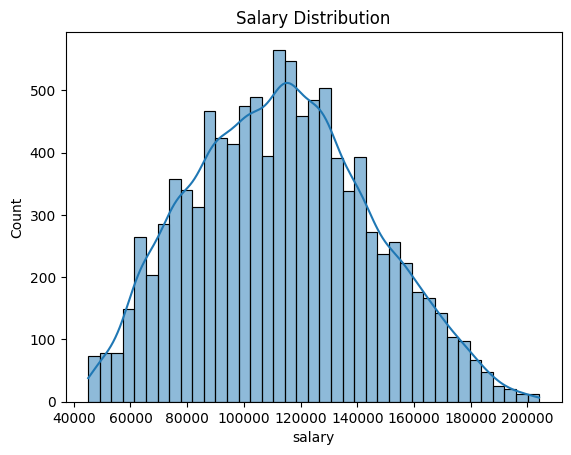

In [6]:
sns.histplot(df['salary'], kde=True)
plt.title("Salary Distribution")
plt.show()

## **Lương trung bình theo kinh nghiệm làm việc** ##

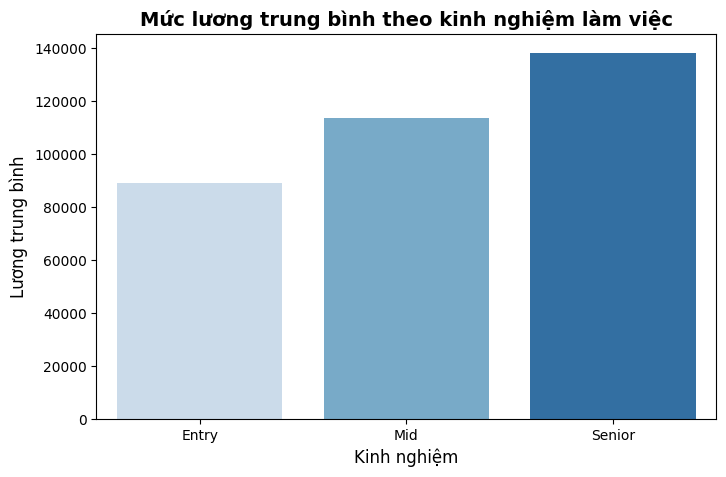

In [7]:
# Tính mức lương trung bình theo từng cấp bậc kinh nghiệm
luong_theo_kinh_nghiem = df.groupby('experience_level')['salary'].mean().sort_values()


plt.figure(figsize=(8, 5))
sns.barplot(x=luong_theo_kinh_nghiem.index, y=luong_theo_kinh_nghiem.values, hue=luong_theo_kinh_nghiem.index, palette='Blues', legend=False)

plt.title('Mức lương trung bình theo kinh nghiệm làm việc', fontsize=14, fontweight='bold')
plt.xlabel('Kinh nghiệm', fontsize=12)
plt.ylabel('Lương trung bình', fontsize=12)
plt.show()

## **Mức lương trung bình theo vị trí việc làm** ##

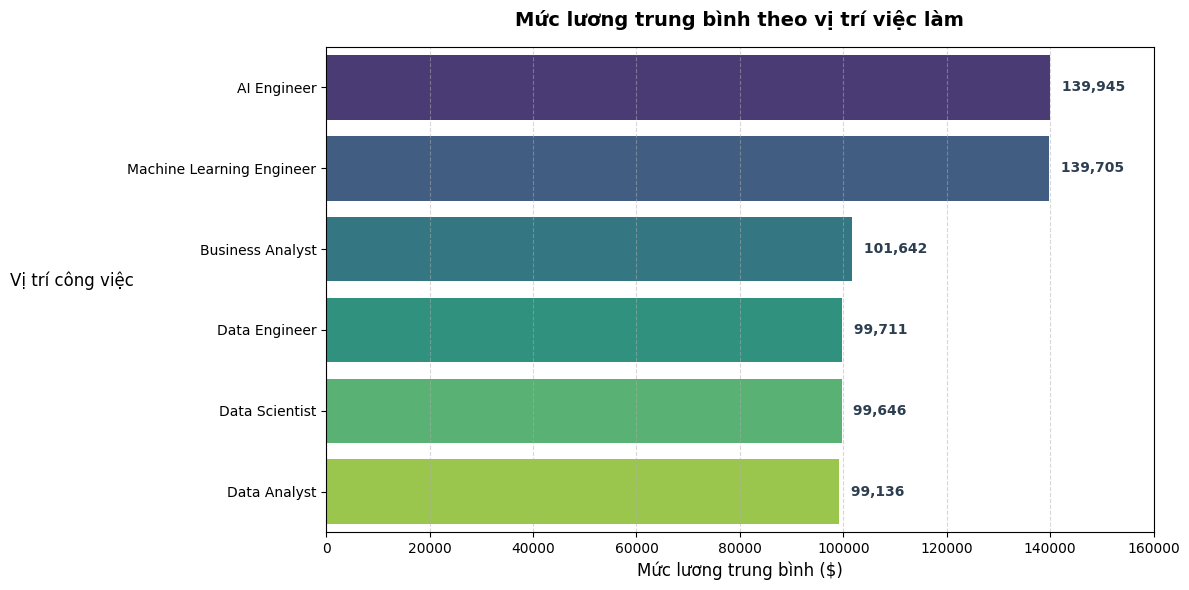

In [8]:
## Mức lương trung bình theo vị trí việc làm (Bản sửa lỗi hiển thị số tiền)

# Tính mức lương trung bình theo từng vị trí việc làm và sắp xếp giảm dần
luong_theo_vi_tri = df.groupby('job_title')['salary'].mean().sort_values(ascending=False)
top_10_luong = luong_theo_vi_tri.head(10).reset_index()

# Khởi tạo biểu đồ
plt.figure(figsize=(12, 6))

# Vẽ biểu đồ cột ngang
ax = sns.barplot(
    data=top_10_luong,
    x='salary', 
    y='job_title', 
    hue='job_title', 
    palette='viridis', 
    legend=False
)

# ĐÃ SỬA: Giới hạn trục X từ 80,000 đến 160,000 theo yêu cầu của bạn
plt.xlim(0, 160000)

# Hiển thị giá trị lương cụ thể kèm ký tự $ ở phía sau đầu cột
for container in ax.containers:
    ax.bar_label(
        container, 
        fmt=lambda x: f' {x:,.0f}' if x > 0 else '', 
        fontweight='bold', 
        fontsize=10, 
        color='#2c3e50',
        padding=5
    )

# Tùy chỉnh tiêu đề và nhãn trục
plt.title('Mức lương trung bình theo vị trí việc làm', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Mức lương trung bình ($)', fontsize=12)

# Ép nhãn trục Y nằm ngang hoàn toàn để sửa lỗi quay dọc chữ
plt.ylabel('Vị trí công việc', fontsize=12, rotation=0, labelpad=40) 

plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

## **Mức lương trung bình theo quốc gia** ##


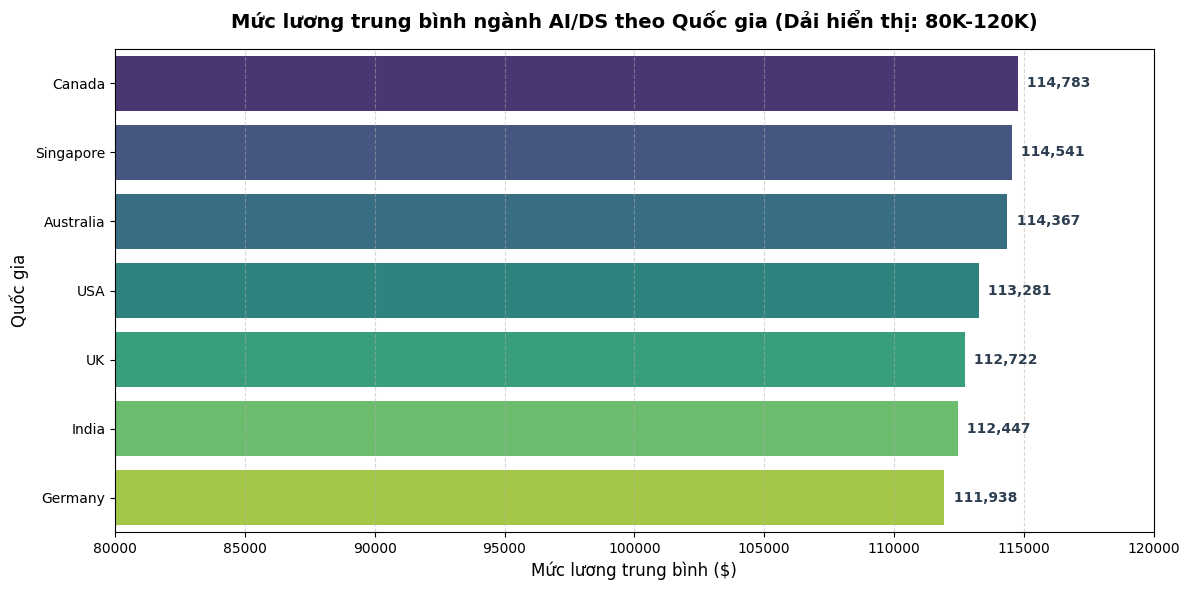

In [9]:
# Tính mức lương trung bình theo từng quốc gia và sắp xếp giảm dần
luong_theo_quoc_gia = df.groupby('country')['salary'].mean().sort_values(ascending=False).reset_index()

# Khởi tạo biểu đồ
fig, ax = plt.subplots(figsize=(12, 6))

# Vẽ biểu đồ cột ngang
sns.barplot(
    data=luong_theo_quoc_gia,
    x='salary', 
    y='country', 
    hue='country', 
    palette='viridis', 
    legend=False,
    ax=ax
)

ax.set_xlim(80000, 120000)

for container in ax.containers:
    ax.bar_label(
        container, 
        fmt=lambda x: f' {x:,.0f}' if x > 0 else '', 
        fontweight='bold', 
        fontsize=10, 
        color='#2c3e50',
        padding=3
    )

ax.set_title('Mức lương trung bình ngành AI/DS theo Quốc gia (Dải hiển thị: 80K-120K)', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Mức lương trung bình ($)', fontsize=12)
ax.set_ylabel('Quốc gia', fontsize=12)
ax.grid(axis='x', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

## **Hiệu suất lương thu nhập / năm kinh nghiệm** ##


--- GIÁ TRỊ TRUNG BÌNH CỦA HIỆU SUẤT LƯƠNG ($/NĂM EXP) ---
education_level      Bachelor        Master           PhD
company_size                                             
Enterprise       23455.623168  25155.072532  23355.702723
MNC              26954.476718  30056.254909  29312.471867
Medium           25497.157364  24729.103823  24821.593303
Startup          23638.547540  22951.213506  24745.498843




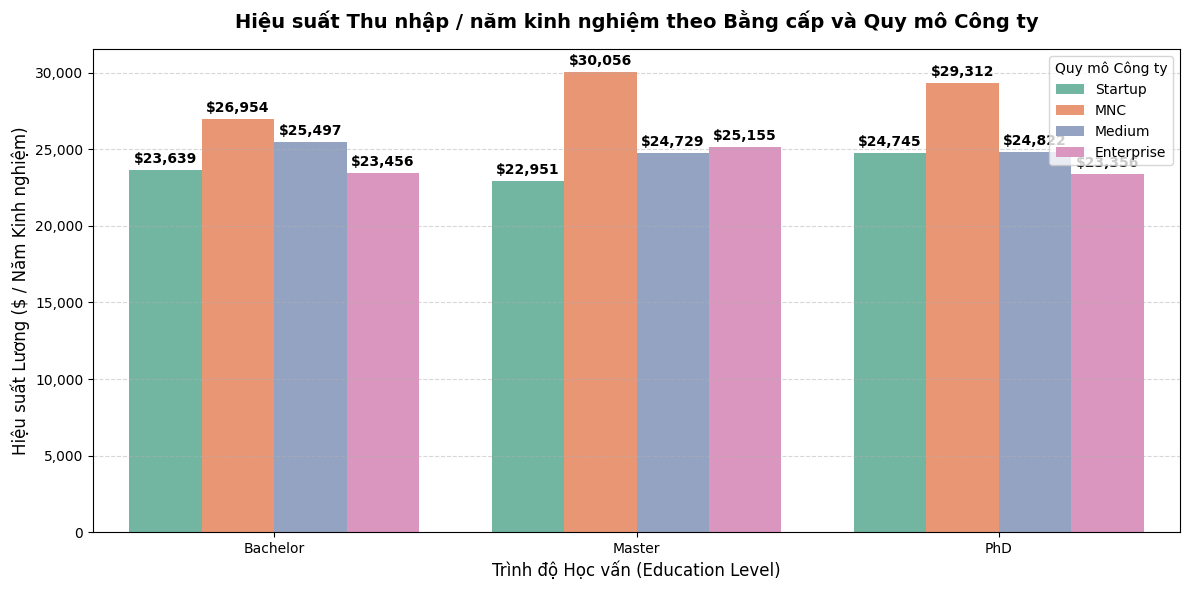

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as ticker

df['Salary_Per_Year_Exp'] = df['salary'] / (df['years_experience'] + 1)

summary_table = df.groupby(['company_size', 'education_level'])['Salary_Per_Year_Exp'].mean().unstack()
print("--- GIÁ TRỊ TRUNG BÌNH CỦA HIỆU SUẤT LƯƠNG ($/NĂM EXP) ---")
print(summary_table)
print("\n")

plt.figure(figsize=(12, 6))

edu_order = ['Bachelor', 'Master', 'PhD']
size_order = ['Startup', 'MNC', 'Medium', 'Enterprise'] 

ax = sns.barplot(
    data=df,
    x='education_level',
    y='Salary_Per_Year_Exp',
    hue='company_size',
    order=edu_order,
    hue_order=size_order,
    palette='Set2',
    errorbar=None 
)

for container in ax.containers:
    ax.bar_label(
        container, 
        fmt=lambda x: f"${x:,.0f}" if x > 0 else '', 
        fontweight='bold', 
        fontsize=10, 
        padding=3
    )

plt.gca().yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, p: format(int(x), ',')))

plt.title('Hiệu suất Thu nhập / năm kinh nghiệm theo Bằng cấp và Quy mô Công ty', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Trình độ Học vấn (Education Level)', fontsize=12)
plt.ylabel('Hiệu suất Lương ($ / Năm Kinh nghiệm)', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.legend(title='Quy mô Công ty', loc='upper right')
plt.tight_layout()
plt.show()

## **Mức lương trung bình theo kĩ năng** ##


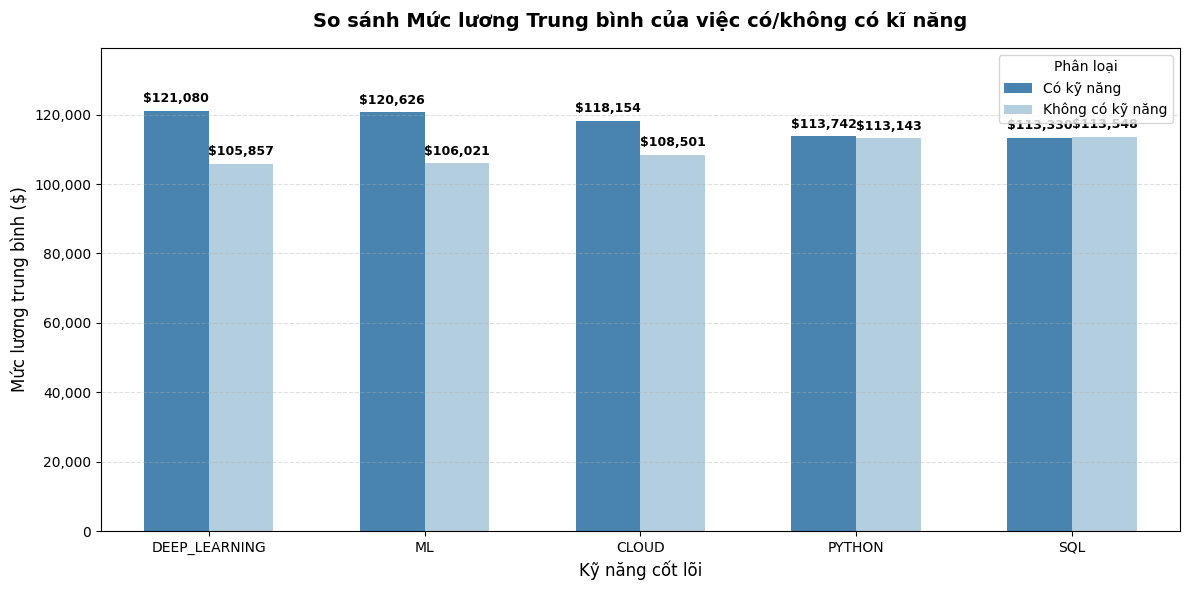

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as ticker

skill_cols = ['skills_python', 'skills_sql', 'skills_ml', 'skills_deep_learning', 'skills_cloud']

formatted_data = []
for skill in skill_cols:
    skill_name = skill.replace('skills_', '').upper()
    
    mean_with = df[df[skill] == 1]['salary'].mean()
    formatted_data.append({'Skill': skill_name, 'Trạng thái': 'Có kỹ năng', 'Lương ($)': mean_with})
    
    mean_without = df[df[skill] == 0]['salary'].mean()
    formatted_data.append({'Skill': skill_name, 'Trạng thái': 'Không có kỹ năng', 'Lương ($)': mean_without})

df_skills_compare = pd.DataFrame(formatted_data)

skill_order = df_skills_compare[df_skills_compare['Trạng thái'] == 'Có kỹ năng'].sort_values(by='Lương ($)', ascending=False)['Skill']


plt.figure(figsize=(12, 6))

ax = sns.barplot(
    data=df_skills_compare,
    x='Skill',
    y='Lương ($)',
    hue='Trạng thái',
    order=skill_order,
    palette='Blues_r', 
    width=0.6
)

for container in ax.containers:
    ax.bar_label(
        container, 
        fmt=lambda x: f"${x:,.0f}", 
        fontweight='bold', 
        fontsize=9, 
        padding=4
    )

plt.gca().yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, p: format(int(x), ',')))

plt.ylim(0, df_skills_compare['Lương ($)'].max() * 1.15)

plt.title('So sánh Mức lương Trung bình của việc có/không có kĩ năng', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Kỹ năng cốt lõi', fontsize=12)
plt.ylabel('Mức lương trung bình ($)', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.legend(title='Phân loại', loc='upper right')
plt.tight_layout()
plt.show()

## **Mức lương trung bình và nhu cầu theo lĩnh vực** ##


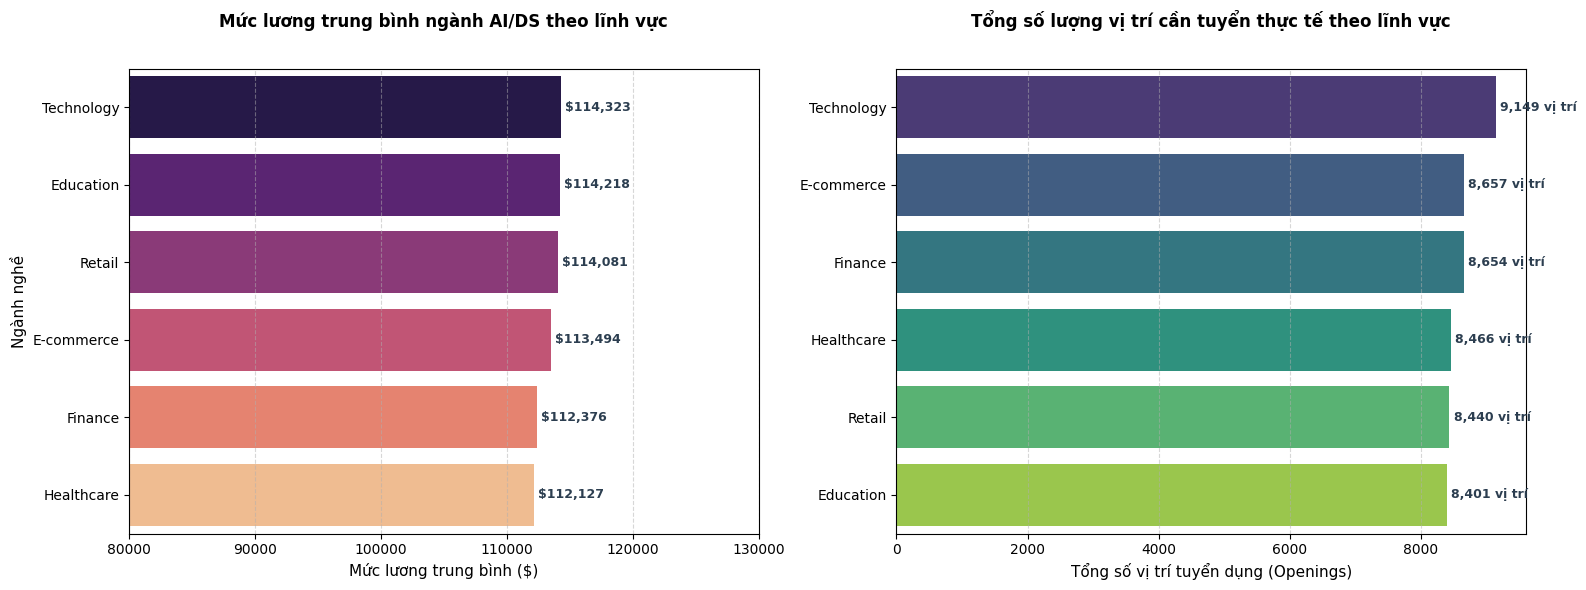

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as ticker

industry_analysis = df.groupby('company_industry').agg(
    luong_trung_binh=('salary', 'mean'),
    tong_vi_tri_tuyen=('job_openings', 'sum')
).reset_index()

industry_salary = industry_analysis.sort_values(by='luong_trung_binh', ascending=False)
industry_demand = industry_analysis.sort_values(by='tong_vi_tri_tuyen', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.barplot(
    data=industry_salary, 
    x='luong_trung_binh', 
    y='company_industry', 
    hue='company_industry',
    palette='magma', 
    legend=False,
    ax=axes[0]
)
axes[0].set_xlim(80000, 130000) 
axes[0].set_title('Mức lương trung bình ngành AI/DS theo lĩnh vực\n', fontsize=12, fontweight='bold', pad=15)
axes[0].set_xlabel('Mức lương trung bình ($)', fontsize=11)
axes[0].set_ylabel('Ngành nghề', fontsize=11)
axes[0].grid(axis='x', linestyle='--', alpha=0.5)


for container in axes[0].containers:
    axes[0].bar_label(container, fmt=lambda x: f"${x:,.0f}" if x > 0 else '', fontweight='bold', fontsize=9, color='#2c3e50', padding=3)

sns.barplot(
    data=industry_demand, 
    x='tong_vi_tri_tuyen', 
    y='company_industry', 
    hue='company_industry',
    palette='viridis', 
    legend=False,
    ax=axes[1]
)
axes[1].set_title('Tổng số lượng vị trí cần tuyển thực tế theo lĩnh vực\n', fontsize=12, fontweight='bold', pad=15)
axes[1].set_xlabel('Tổng số vị trí tuyển dụng (Openings)', fontsize=11)
axes[1].set_ylabel('') 
axes[1].grid(axis='x', linestyle='--', alpha=0.5)

for container in axes[1].containers:
    axes[1].bar_label(container, fmt=lambda x: f"{x:,.0f} vị trí" if x > 0 else '', fontweight='bold', fontsize=9, color='#2c3e50', padding=3)

plt.tight_layout()
plt.show()

## **Nhu cầu tuyển dụng theo năm** ##


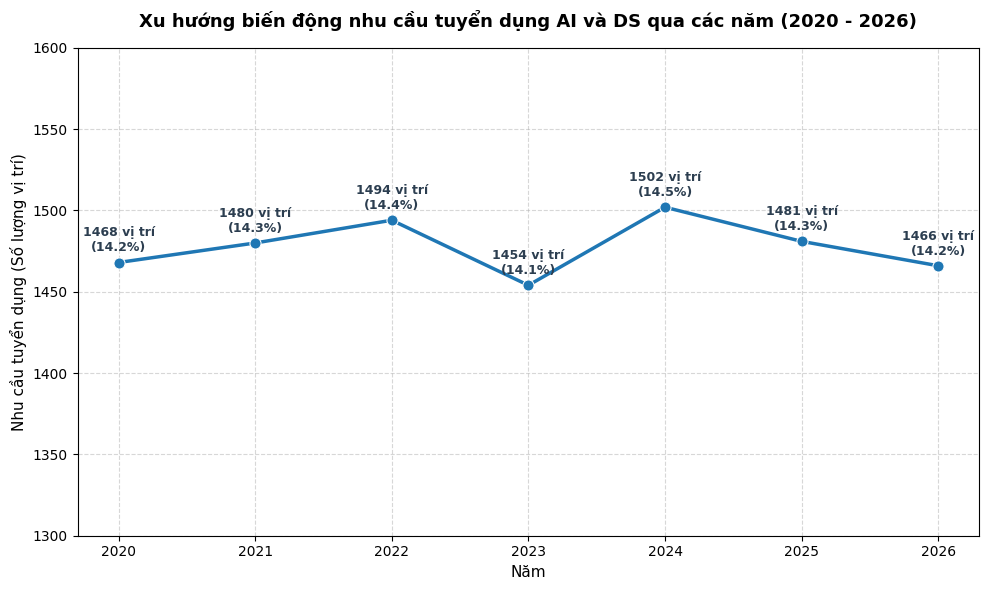

In [13]:
# CHUẨN BỊ DỮ LIỆU
trend_year_table = df.groupby('job_posting_year').size().reset_index(name='Nhu cầu tuyển dụng')
tong_so_tri = trend_year_table['Nhu cầu tuyển dụng'].sum()
trend_year_table['Tỷ lệ (%)'] = round((trend_year_table['Nhu cầu tuyển dụng'] / tong_so_tri) * 100, 1)
trend_year_table = trend_year_table.rename(columns={'job_posting_year': 'Năm'})

# VẼ BIỂU ĐỒ
plt.figure(figsize=(10, 6))

# Vẽ biểu đồ đường
sns.lineplot(
    data=trend_year_table, 
    x='Năm', 
    y='Nhu cầu tuyển dụng', 
    marker='o', 
    markersize=8, 
    linewidth=2.5, 
    color='#1f77b4'
)

# Hiển thị số liệu dạng: "1468 vị trí (14.2%)"
for i in range(len(trend_year_table)):
    plt.text(
        x=trend_year_table['Năm'].iloc[i], 
        y=trend_year_table['Nhu cầu tuyển dụng'].iloc[i] + 5,  # Đã chỉnh thành +5 để phù hợp với tỉ lệ trục mới
        s=f"{trend_year_table['Nhu cầu tuyển dụng'].iloc[i]} vị trí\n({trend_year_table['Tỷ lệ (%)'].iloc[i]}%)", 
        ha='center', 
        va='bottom', 
        fontsize=9, 
        fontweight='bold', 
        color='#2c3e50'
    )

# Tùy chỉnh tiêu đề và trục
plt.title('Xu hướng biến động nhu cầu tuyển dụng AI và DS qua các năm (2020 - 2026)', fontsize=13, fontweight='bold', pad=15)
plt.xlabel('Năm', fontsize=11)
plt.ylabel('Nhu cầu tuyển dụng (Số lượng vị trí)', fontsize=11)
plt.xticks(trend_year_table['Năm'])


plt.ylim(1300, 1600) 

plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

Nhu cầu tuyển dụng ngành AI/DS duy trì ở mức cao và tương đối ổn định qua các năm (gần 1500 vị trí/năm). Thị trường chỉ giảm nhẹ vào năm 2023 ($1454$ vị trí).
Năm 2023, sự sụt giảm nhân lực trong ngành Trí tuệ nhân tạo (AI) và Khoa học dữ liệu (Data Science - DS) chủ yếu xuất phát từ làn sóng cắt giảm chi phí, sự điều chỉnh sau đợt tuyển dụng ồ ạt thời đại dịch và việc tái cơ cấu nguồn vốn để tập trung đầu tư vào cơ sở hạ tầng AI. (Theo báo pháp luật TP.Hồ Chí Minh)
https://plo.vn/thay-gi-tu-lan-song-cat-giam-nhan-su-thoi-gian-qua-post775191.html

## **Nhu cầu tuyển dụng theo tháng** ##


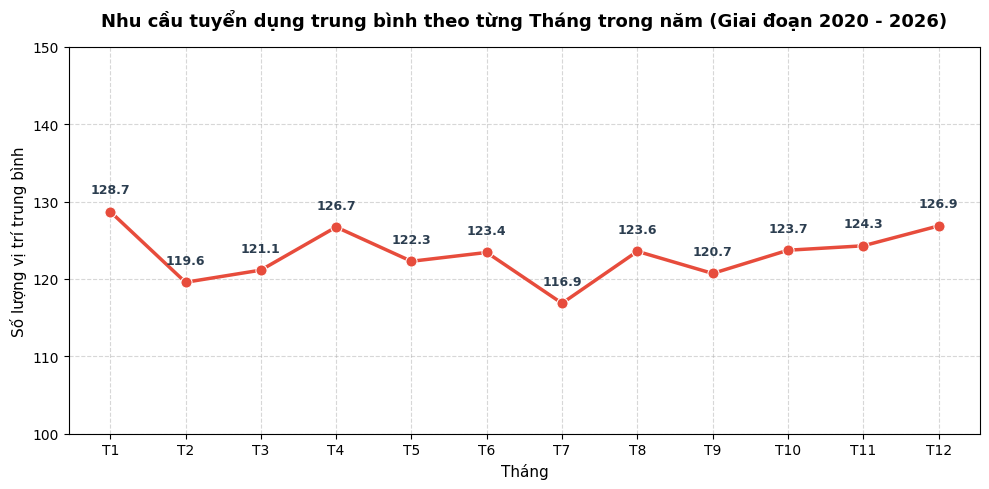

In [14]:
# 1. CHUẨN BỊ DỮ LIỆU: Tính trung bình số lượng vị trí tuyển dụng của từng tháng qua các năm
# Bước a: Gom nhóm theo Năm và Tháng để có số lượng của từng tháng trong mỗi năm cụ thể
month_year_counts = df.groupby(['job_posting_year', 'job_posting_month']).size().reset_index(name='Số lượng')

# Bước b: Tính trung bình bằng cách gom nhóm theo Tháng và chia cho tổng số năm (cộng tổng rồi chia trung bình)
trend_avg_month = month_year_counts.groupby('job_posting_month')['Số lượng'].mean().reset_index(name='Lượng tuyển dụng trung bình')

trend_avg_month['Tháng'] = trend_avg_month['job_posting_month'].apply(lambda x: f"T{x}")

# 2. VẼ BIỂU ĐỒ XU HƯỚNG TRUNG BÌNH THEO THÁNG
plt.figure(figsize=(10, 5))
sns.lineplot(
    data=trend_avg_month, 
    x='Tháng', 
    y='Lượng tuyển dụng trung bình', 
    marker='o', 
    markersize=8,
    linewidth=2.5, 
    color='#e74c3c' 
)

for i in range(len(trend_avg_month)):
    plt.text(
        x=trend_avg_month['Tháng'].iloc[i], 
        y=trend_avg_month['Lượng tuyển dụng trung bình'].iloc[i] + 2,  # Đẩy chữ lên trên nút tròn một chút
        s=f"{trend_avg_month['Lượng tuyển dụng trung bình'].iloc[i]:.1f}", # Lấy 1 chữ số thập phân
        ha='center', 
        va='bottom', 
        fontsize=9, 
        fontweight='bold', 
        color='#2c3e50'
    )

# Tùy chỉnh trang trí
plt.title('Nhu cầu tuyển dụng trung bình theo từng Tháng trong năm (Giai đoạn 2020 - 2026)', fontsize=13, fontweight='bold', pad=15)
plt.xlabel('Tháng', fontsize=11)
plt.ylabel('Số lượng vị trí trung bình', fontsize=11)
plt.ylim(100, 150) 
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

Theo phân tích các luồng ý kiến trên trang https://www.quora.com/How-seasonal-is-data-science-hiring,
đa số bình luận cho rằng ngành này ít mang tính thời vụ (seasonal) so với nhiều lĩnh vực khác. Nhưng các chuyên gia cũng có lí giải về xu hướng tuyển dụng như sau:

Xu hướng giữa năm (T7-T9): Nhu cầu tuyển dụng chậm lại vào Tháng 7 ($116.9$ vị trí) do mùa nghỉ hè quản lý và nhân viên HR có thể nghỉ lễ. Điều này khiến việc xếp lịch phỏng vấn và làm thủ tục nhận việc bị trì hoãn. Sau đó sẽ phục hồi vào Tháng 8 ($123.6$ vị trí) và ổn định lại trong Tháng 9 khi kì nghỉ kết thúc.

Xu hướng cuối năm (T10-T12): Thị trường tăng mạng và cao nhất vào Tháng 12 ($126.9$ vị trí) do các doanh nghiệp chạy nước rút hoàn thành chỉ tiêu ngân sách và chuẩn bị nhân sự cho năm mới.

## **Mức lương trung bình theo chế độ làm việc** ##

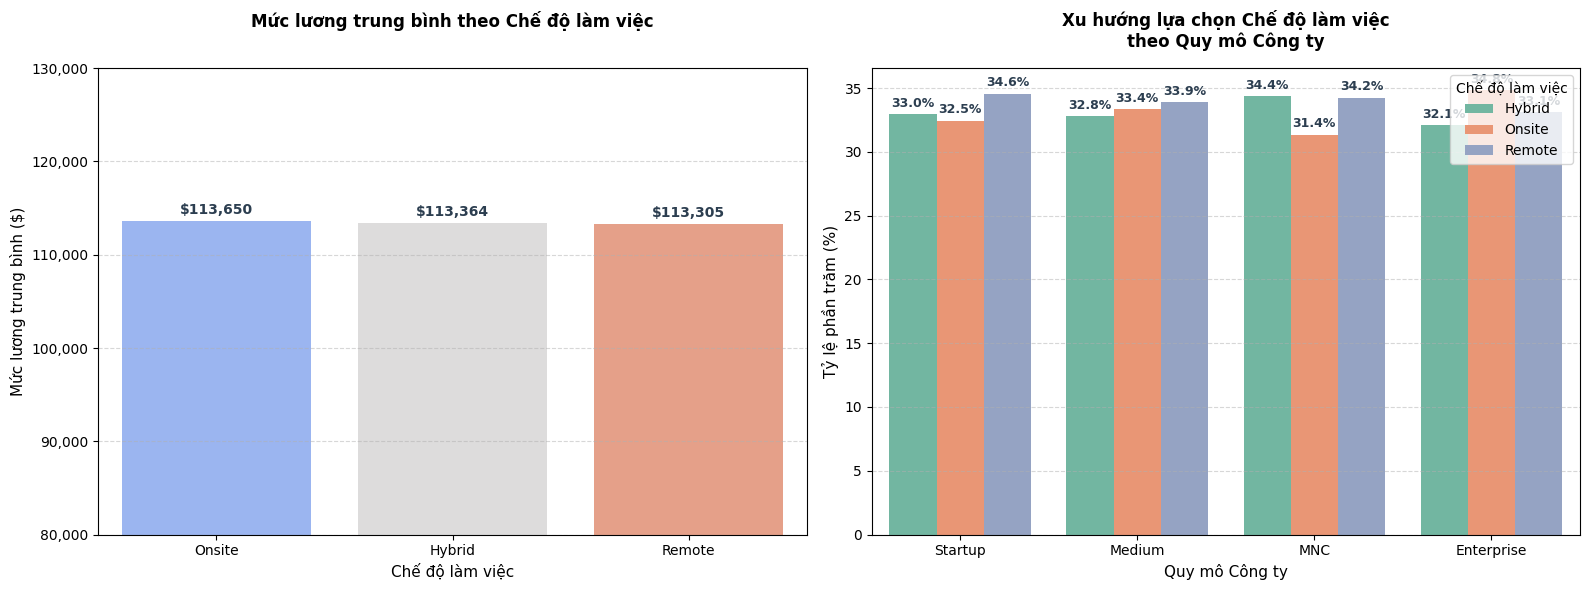

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as ticker

remote_salary = df.groupby('remote_type')['salary'].mean().reset_index().sort_values(by='salary', ascending=False)

company_remote = df.groupby(['company_size', 'remote_type']).size().unstack(fill_value=0)
company_remote_pct = company_remote.div(company_remote.sum(axis=1), axis=0) * 100
company_remote_melt = company_remote_pct.reset_index().melt(id_vars='company_size', value_name='Tỷ lệ (%)', var_name='Chế độ làm việc')

size_order = ['Startup', 'Medium', 'MNC', 'Enterprise']

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.barplot(
    data=remote_salary, 
    x='remote_type', 
    y='salary', 
    hue='remote_type',
    palette='coolwarm', 
    legend=False,
    ax=axes[0]
)
axes[0].set_ylim(80000, 130000) 
axes[0].set_title('Mức lương trung bình theo Chế độ làm việc\n', fontsize=12, fontweight='bold', pad=15)
axes[0].set_xlabel('Chế độ làm việc', fontsize=11)
axes[0].set_ylabel('Mức lương trung bình ($)', fontsize=11)
axes[0].grid(axis='y', linestyle='--', alpha=0.5)

axes[0].yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, p: format(int(x), ',')))

for container in axes[0].containers:
    axes[0].bar_label(container, fmt=lambda x: f"${x:,.0f}" if x > 0 else '', fontweight='bold', fontsize=10, color='#2c3e50', padding=3)


sns.barplot(
    data=company_remote_melt, 
    x='company_size', 
    y='Tỷ lệ (%)', 
    hue='Chế độ làm việc', 
    order=size_order,
    palette='Set2',
    ax=axes[1]
)
axes[1].set_title('Xu hướng lựa chọn Chế độ làm việc\ntheo Quy mô Công ty', fontsize=12, fontweight='bold', pad=15)
axes[1].set_xlabel('Quy mô Công ty', fontsize=11)
axes[1].set_ylabel('Tỷ lệ phần trăm (%)', fontsize=11)
axes[1].grid(axis='y', linestyle='--', alpha=0.5)
axes[1].legend(title='Chế độ làm việc', loc='upper right')

for container in axes[1].containers:
    axes[1].bar_label(container, fmt=lambda x: f"{x:.1f}%" if x > 0 else '', fontweight='bold', fontsize=9, color='#2c3e50', padding=3)

plt.tight_layout()
plt.show()

## **Dự đoán nhu cầu tuyển dụng năm 2027** ##

15:05:56 - cmdstanpy - INFO - Chain [1] start processing
15:05:57 - cmdstanpy - INFO - Chain [1] done processing


====== KẾT QUẢ KIỂM TRA MÔ HÌNH PROPHET ======
Mean Absolute Error (MAE): 10.95 vị trí
Root Mean Squared Error (RMSE): 14.08 vị trí
Mean Absolute Percentage Error (MAPE): 8.67%


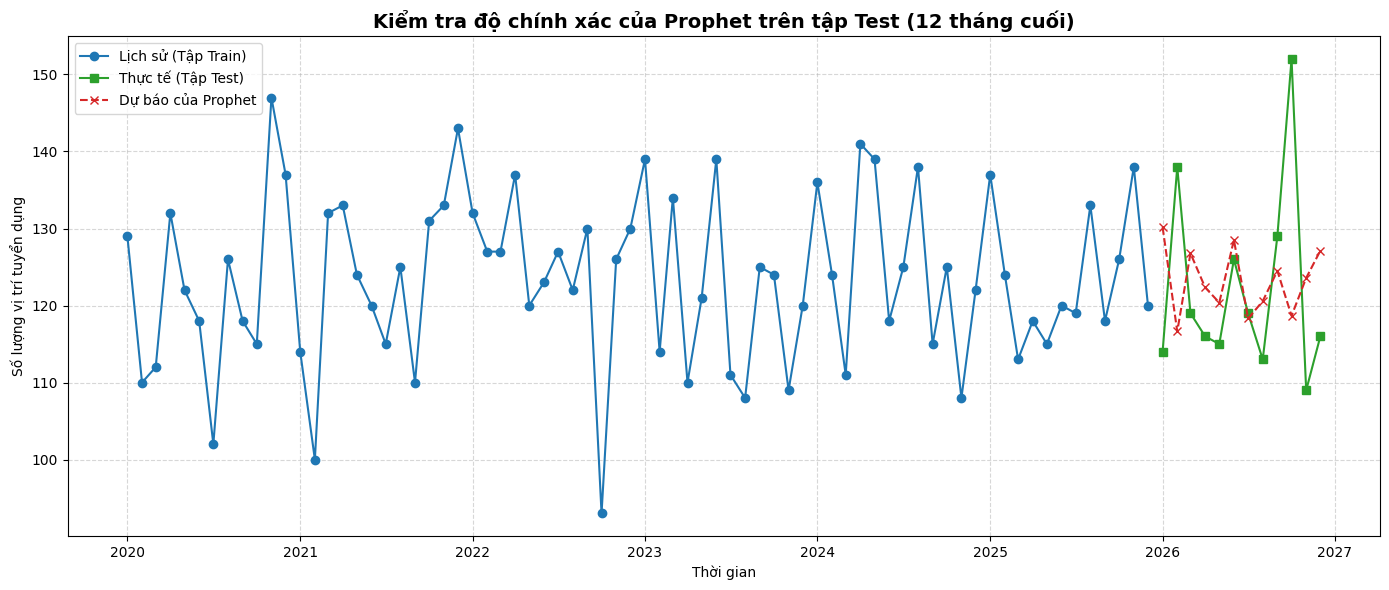

15:05:58 - cmdstanpy - INFO - Chain [1] start processing
15:05:59 - cmdstanpy - INFO - Chain [1] done processing


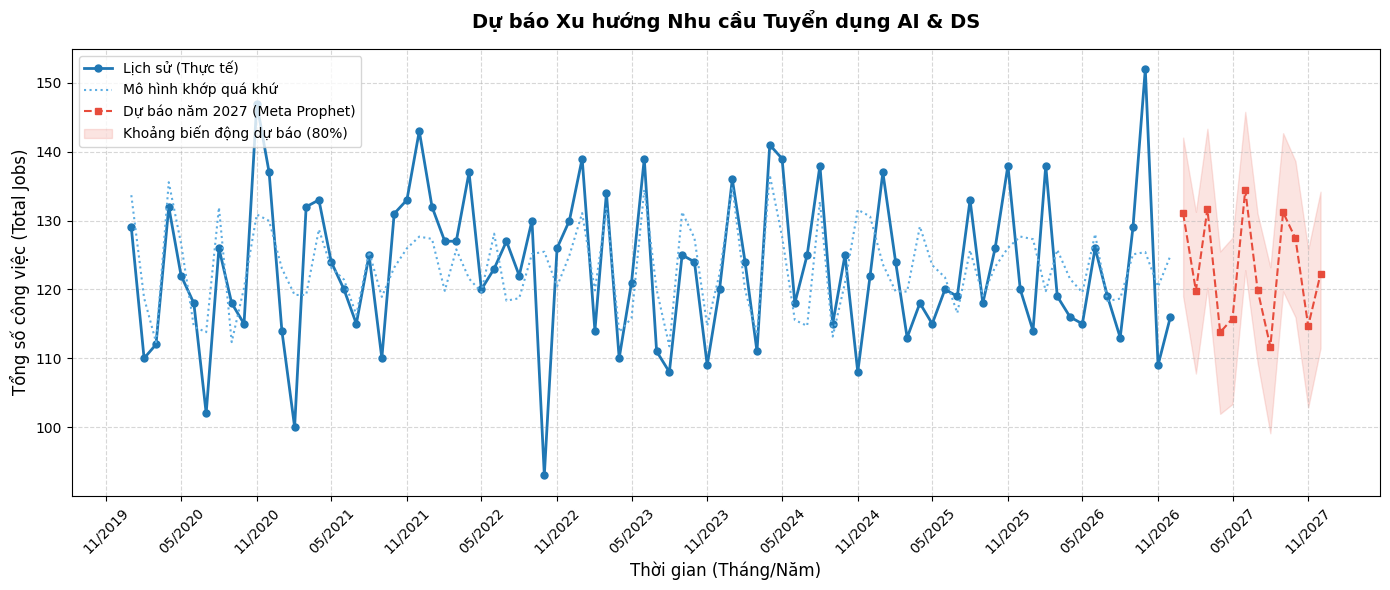

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from sklearn.metrics import mean_absolute_error, mean_squared_error
from prophet import Prophet


ts_data = df.groupby(['job_posting_year', 'job_posting_month']).size().reset_index(name='y')
ts_data['ds'] = pd.to_datetime(ts_data['job_posting_year'].astype(str) + '-' + ts_data['job_posting_month'].astype(str) + '-01')
df_prophet = ts_data[['ds', 'y']].sort_values('ds').reset_index(drop=True)


train_df = df_prophet.iloc[:-12]
test_df = df_prophet.iloc[-12:]

model_eval = Prophet(
    yearly_seasonality=True, 
    weekly_seasonality=False, 
    daily_seasonality=False, 
    changepoint_prior_scale=0.08
)
model_eval.fit(train_df)

future_eval = model_eval.make_future_dataframe(periods=12, freq='MS')
forecast_eval = model_eval.predict(future_eval)

pred_df = forecast_eval.iloc[-12:][['ds', 'yhat']]

mae = mean_absolute_error(test_df['y'], pred_df['yhat'])
rmse = np.sqrt(mean_squared_error(test_df['y'], pred_df['yhat']))
mape = np.mean(np.abs((test_df['y'].values - pred_df['yhat'].values) / test_df['y'].values)) * 100

print("====== KẾT QUẢ KIỂM TRA MÔ HÌNH PROPHET ======")
print(f"Mean Absolute Error (MAE): {mae:.2f} vị trí")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f} vị trí")
print(f"Mean Absolute Percentage Error (MAPE): {mape:.2f}%")
print("===============================================")

plt.figure(figsize=(14, 6))
plt.plot(train_df['ds'], train_df['y'], label='Lịch sử (Tập Train)', color='#1f77b4', marker='o')
plt.plot(test_df['ds'], test_df['y'], label='Thực tế (Tập Test)', color='#2ca02c', marker='s')
plt.plot(pred_df['ds'], pred_df['yhat'], label='Dự báo của Prophet', color='#d62728', linestyle='--', marker='x')
plt.title('Kiểm tra độ chính xác của Prophet trên tập Test (12 tháng cuối)', fontsize=14, fontweight='bold')
plt.xlabel('Thời gian')
plt.ylabel('Số lượng vị trí tuyển dụng')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()

model = Prophet(
    yearly_seasonality=True,   
    weekly_seasonality=False,  
    daily_seasonality=False,   
    changepoint_prior_scale=0.08, 
    interval_width=0.80        
)
model.fit(df_prophet)

future = model.make_future_dataframe(periods=12, freq='MS')
forecast = model.predict(future)

df_past_pred = forecast[forecast['ds'] <= df_prophet['ds'].max()]
df_future_2027 = forecast[forecast['ds'] > df_prophet['ds'].max()]

plt.figure(figsize=(14, 6))

plt.plot(df_prophet['ds'], df_prophet['y'], label='Lịch sử (Thực tế)', color='#1f77b4', marker='o', markersize=5, linewidth=2)

plt.plot(df_past_pred['ds'], df_past_pred['yhat'], color='#5dade2', linestyle=':', label='Mô hình khớp quá khứ')

plt.plot(df_future_2027['ds'], df_future_2027['yhat'], label='Dự báo năm 2027 (Meta Prophet)', color='#e74c3c', linestyle='--', marker='s', markersize=5)

plt.fill_between(df_future_2027['ds'], df_future_2027['yhat_lower'], df_future_2027['yhat_upper'], color='#e74c3c', alpha=0.15, label='Khoảng biến động dự báo (80%)')

plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%m/%Y'))
plt.gca().xaxis.set_major_locator(mdates.MonthLocator(interval=6))
plt.xticks(rotation=45)

plt.title('Dự báo Xu hướng Nhu cầu Tuyển dụng AI & DS', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Thời gian (Tháng/Năm)', fontsize=12)
plt.ylabel('Tổng số công việc (Total Jobs)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(fontsize=10, loc='upper left')
plt.tight_layout()
plt.show()

## **** ##

====== KẾT QUẢ ĐÁNH GIÁ MÔ HÌNH DỰ ĐOÁN LƯƠNG ======
Độ chính xác (R2 Score): 98.66%
Sai số tuyệt đối trung bình (MAE): $2,843.20 / năm
Sai số bình phương trung bình (RMSE): $3,655.03 / năm


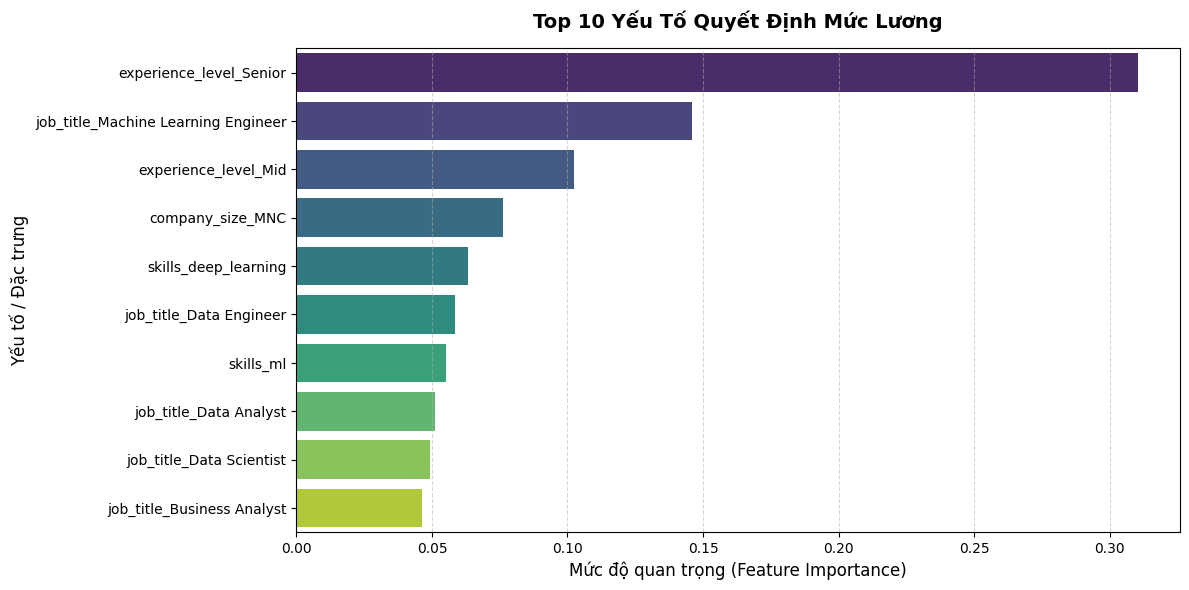

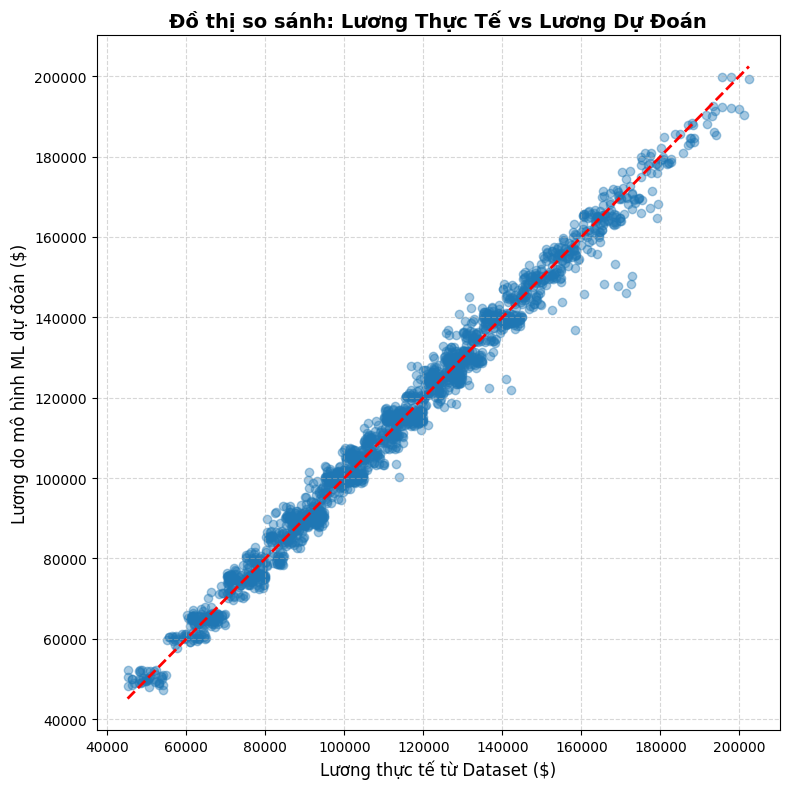

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error


df_ml = df.copy()

features = [
    'job_title', 'company_size', 'experience_level', 'years_experience', 
    'education_level', 'skills_python', 'skills_sql', 'skills_ml', 
    'skills_deep_learning', 'skills_cloud'
]
X = df_ml[features]
y = df_ml['salary']

X_encoded = pd.get_dummies(X, drop_first=True)

X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, test_size=0.2, random_state=42)

rf_salary_model = RandomForestRegressor(n_estimators=150, max_depth=12, random_state=42)
rf_salary_model.fit(X_train, y_train)

y_pred = rf_salary_model.predict(X_test)
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("====== KẾT QUẢ ĐÁNH GIÁ MÔ HÌNH DỰ ĐOÁN LƯƠNG ======")
print(f"Độ chính xác (R2 Score): {r2 * 100:.2f}%")
print(f"Sai số tuyệt đối trung bình (MAE): ${mae:,.2f} / năm")
print(f"Sai số bình phương trung bình (RMSE): ${rmse:,.2f} / năm")
print("====================================================")

importances = rf_salary_model.feature_importances_
indices = np.argsort(importances)[::-1]
top_n = 10  

plt.figure(figsize=(12, 6))
sns.barplot(x=importances[indices][:top_n], y=X_encoded.columns[indices][:top_n], hue=X_encoded.columns[indices][:top_n], palette='viridis', legend=False)
plt.title('Top 10 Yếu Tố Quyết Định Mức Lương', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Mức độ quan trọng (Feature Importance)', fontsize=12)
plt.ylabel('Yếu tố / Đặc trưng', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 8))
plt.scatter(y_test, y_pred, alpha=0.4, color='#1f77b4')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.title('Đồ thị so sánh: Lương Thực Tế vs Lương Dự Đoán', fontsize=14, fontweight='bold')
plt.xlabel('Lương thực tế từ Dataset ($)', fontsize=12)
plt.ylabel('Lương do mô hình ML dự đoán ($)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()